In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def _plot_ttft_on_ax(ax, df, sweep_col, prefixes, title):
    """Plot stacked TTFT breakdown bars on a given axes."""
    sweep_vals = df[sweep_col].values

    components = ['prefill_q', 'prefill_time', 'kv_xfer', 'residual']
    comp_labels = ['Queuing', 'Prefill', 'KV Transfer', 'Residual']

    scenario_palettes = {
        0: ['#1a5276', '#2980b9', '#5dade2', '#aed6f1'],  # blues
        1: ['#7b241c', '#c0392b', '#e74c3c', '#f1948a'],  # reds
        2: ['#1e8449', '#27ae60', '#52be80', '#a9dfbf'],  # greens
    }
    scenario_display_names = {
        's1': 'Same PCIe Tree',
        's2': 'Diff PCIe Tree (Same NUMA)',
        's2r2': 'Diff PCIe Tree (Same NUMA)',
        's3': 'Diff NUMA',
        's3r2': 'Diff NUMA',
    }
    comp_hatches = ['///', '', 'xxx', '...']

    n_scenarios = len(prefixes)
    n_points = len(sweep_vals)
    bar_width = 0.25

    x_positions = np.arange(n_points)

    for si, prefix in enumerate(prefixes):
        bottoms = np.zeros(n_points)
        bar_x = x_positions + (si - (n_scenarios - 1) / 2) * bar_width

        for ci, comp in enumerate(components):
            col_name = f'{prefix}-{comp}'
            if col_name not in df.columns:
                continue
            vals = df[col_name].fillna(0).values
            palette = scenario_palettes.get(si, scenario_palettes[0])

            ax.bar(
                bar_x, vals, bar_width,
                bottom=bottoms,
                color=palette[ci],
                hatch=comp_hatches[ci],
                edgecolor='white',
                linewidth=0.5,
            )
            bottoms += vals

    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(v) for v in sweep_vals], fontsize=13)
    ax.set_xlabel(sweep_col.upper(), fontsize=15, fontweight='bold')
    ax.set_ylabel('TTFT (ms)', fontsize=15, fontweight='bold')
    ax.set_title(title, fontsize=17, fontweight='bold')
    ax.tick_params(axis='y', labelsize=13)

    # Component legend in top-to-bottom order (matching visual stacking)
    comp_handles = []
    for ci in reversed(range(len(comp_labels))):
        patch = mpatches.Patch(
            facecolor='#cccccc', hatch=comp_hatches[ci],
            edgecolor='black', label=comp_labels[ci],
        )
        comp_handles.append(patch)

    scenario_handles = []
    for si, prefix in enumerate(prefixes):
        display = scenario_display_names.get(prefix, prefix.upper())
        patch = mpatches.Patch(
            facecolor=scenario_palettes.get(si, scenario_palettes[0])[1],
            edgecolor='black', label=display,
        )
        scenario_handles.append(patch)

    leg1 = ax.legend(handles=scenario_handles, loc='upper left',
                     title='Scenario', fontsize=12, title_fontsize=13)
    ax.add_artist(leg1)
    ax.legend(handles=comp_handles, loc='upper center',
              title='Component', fontsize=12, title_fontsize=13)

    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)


def plot_ttft_breakdown(csv_path, title=None, figsize=(14, 8), split_at=None):
    """Plot stacked bar chart of TTFT breakdown from a -ttft.csv file.

    Args:
        csv_path: Path to the -ttft.csv file.
        title: Base title for the plot(s).
        figsize: Figure size for each plot.
        split_at: If set, split into two plots: sweep values <= split_at
                  and > split_at for better y-axis resolution.
    """
    df = pd.read_csv(csv_path)
    sweep_col = df.columns[0]

    prefixes = []
    seen = set()
    for col in df.columns[1:]:
        prefix = col.split('-')[0]
        if prefix not in seen:
            seen.add(prefix)
            prefixes.append(prefix)

    if title is None:
        title = f'TTFT Breakdown by {sweep_col.upper()} across Scenarios'

    if split_at is not None:
        df_lo = df[df[sweep_col] <= split_at].reset_index(drop=True)
        df_hi = df[df[sweep_col] > split_at].reset_index(drop=True)

        figs = []
        if len(df_lo) > 0:
            fig_lo, ax_lo = plt.subplots(figsize=figsize)
            _plot_ttft_on_ax(ax_lo, df_lo, sweep_col, prefixes,
                             f'{title}\n({sweep_col.upper()} \u2264 {split_at})')
            plt.tight_layout()
            plt.show()
            figs.append(fig_lo)

        if len(df_hi) > 0:
            fig_hi, ax_hi = plt.subplots(figsize=figsize)
            _plot_ttft_on_ax(ax_hi, df_hi, sweep_col, prefixes,
                             f'{title}\n({sweep_col.upper()} > {split_at})')
            plt.tight_layout()
            plt.show()
            figs.append(fig_hi)

        return figs
    else:
        fig, ax = plt.subplots(figsize=figsize)
        _plot_ttft_on_ax(ax, df, sweep_col, prefixes, title)
        plt.tight_layout()
        plt.show()
        return fig

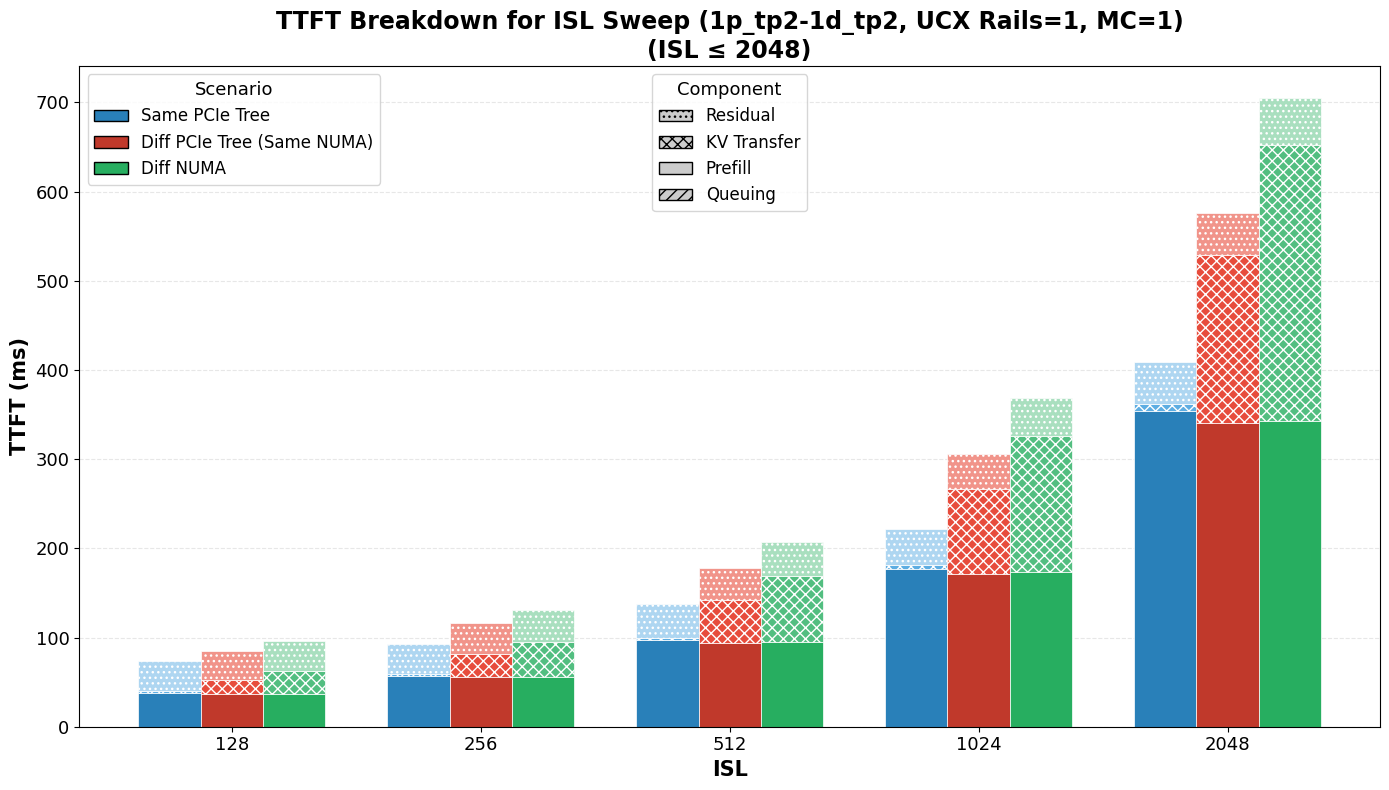

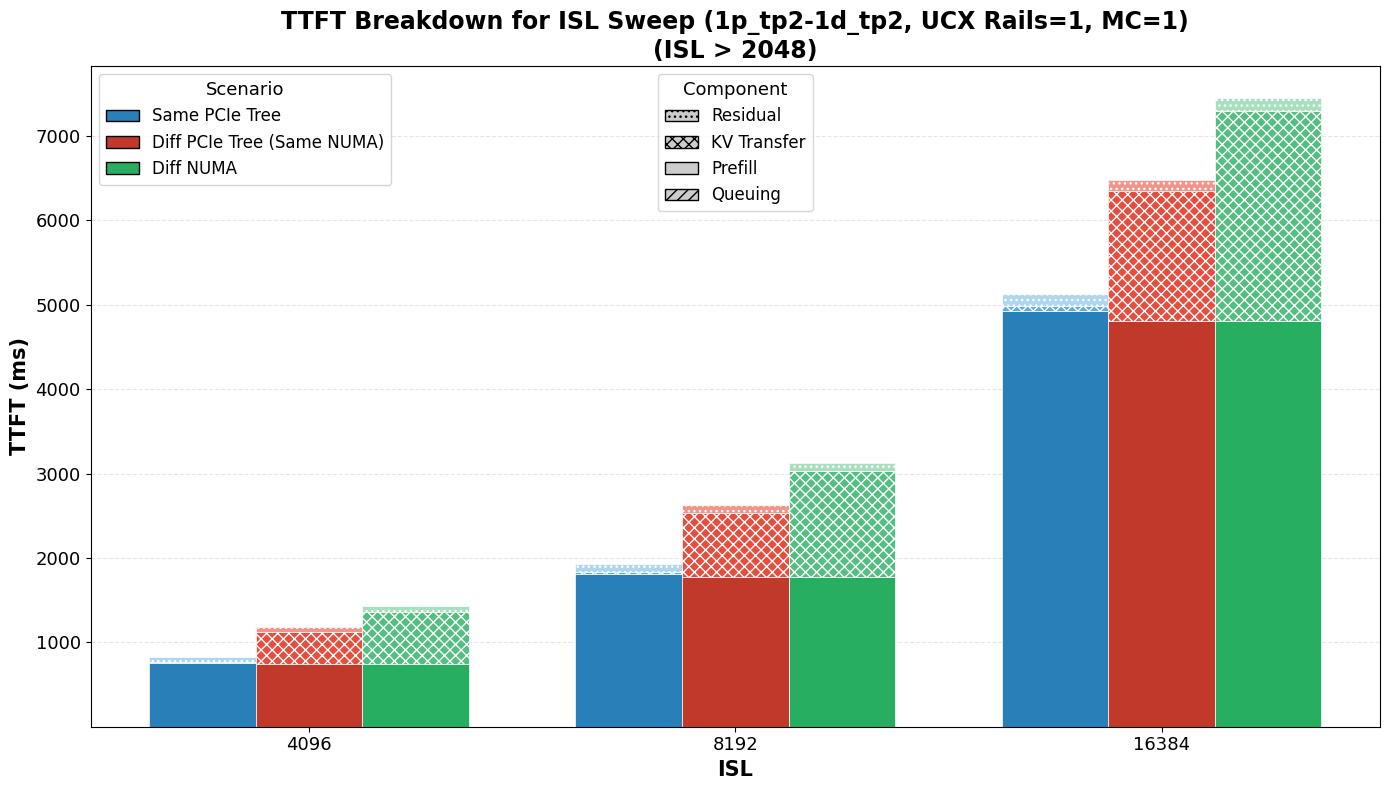

[<Figure size 1400x800 with 1 Axes>, <Figure size 1400x800 with 1 Axes>]

In [9]:
plot_ttft_breakdown(
    '../mc1_basic_isl_sweep/mc1_basic_isl_sweep-ttft.csv',
    title='TTFT Breakdown for ISL Sweep (1p_tp2-1d_tp2, UCX Rails=1, MC=1)',
    split_at=2048,
)

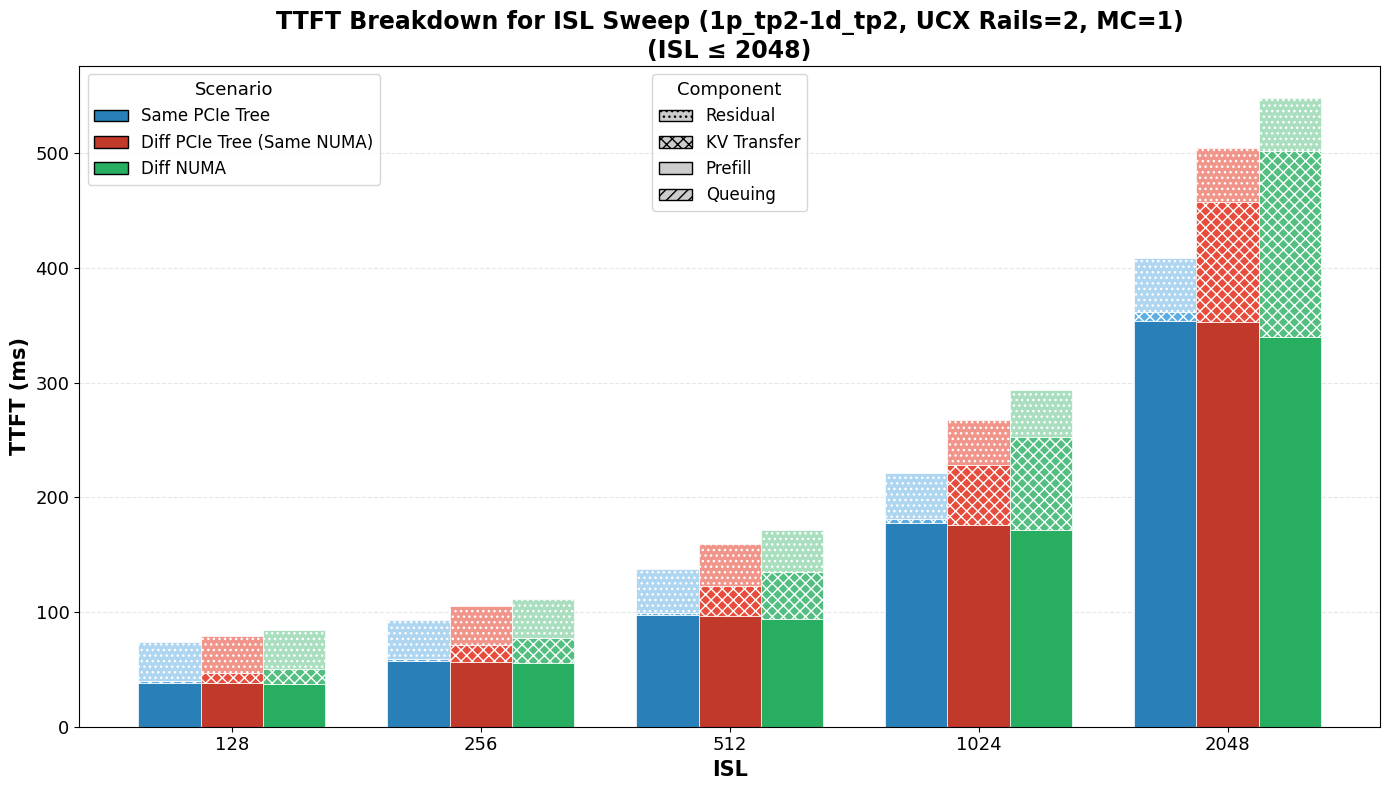

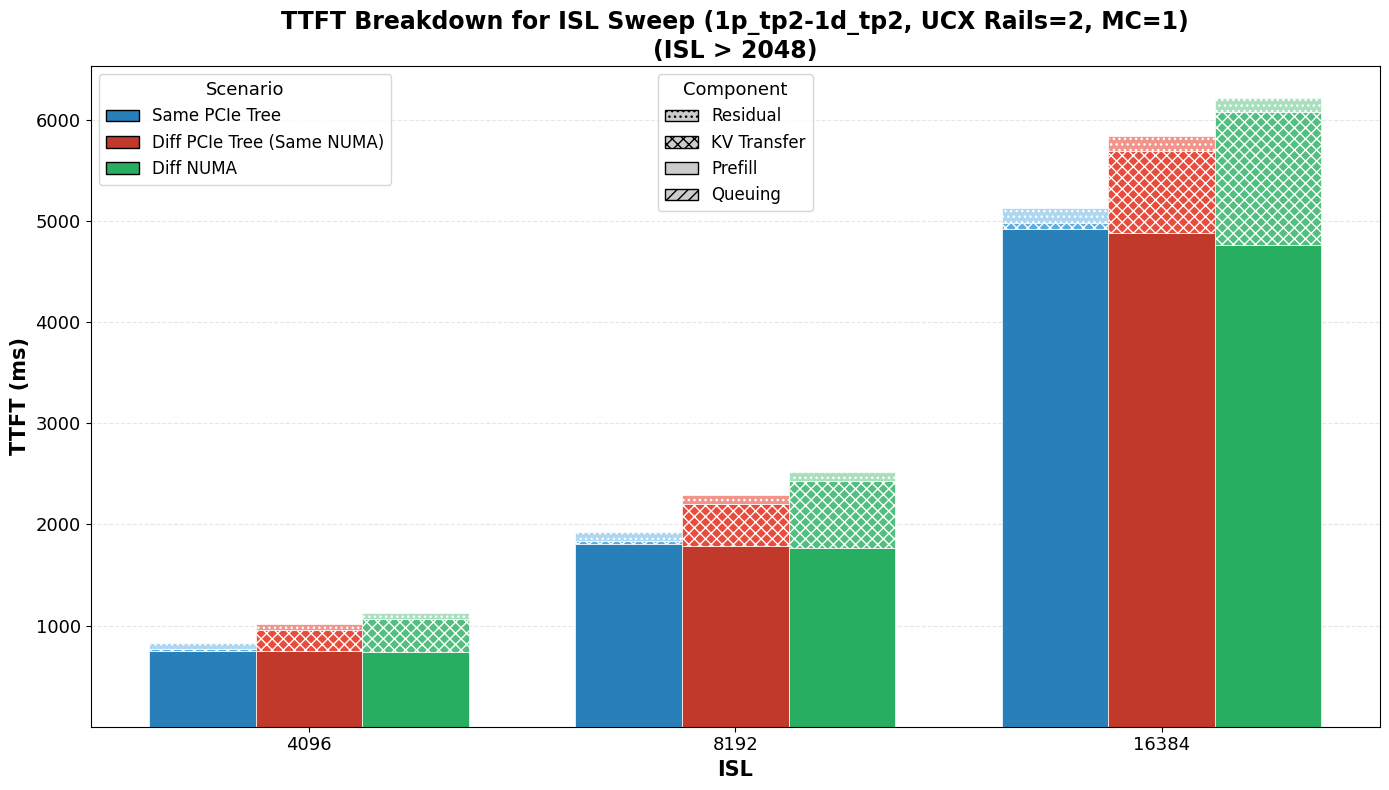

[<Figure size 1400x800 with 1 Axes>, <Figure size 1400x800 with 1 Axes>]

In [10]:
plot_ttft_breakdown(
    '../mc1_rails2_isl_sweep/mc1_rails2_isl_sweep-ttft.csv',
    title='TTFT Breakdown for ISL Sweep (1p_tp2-1d_tp2, UCX Rails=2, MC=1)',
    split_at=2048,
)

In [21]:
SCENARIO_DISPLAY_NAMES = {
    's1': 'Same PCIe Tree',
    's2': 'Diff PCIe Tree (Same NUMA)',
    's2r2': 'Diff PCIe Tree (Same NUMA) [2 rails]',
    's3': 'Diff NUMA',
    's3r2': 'Diff NUMA [2 rails]',
}

SCENARIO_COLORS = {
    's1': '#2980b9',
    's2': '#c0392b',
    's2r2': '#c0392b',
    's3': '#27ae60',
    's3r2': '#27ae60',
}

SCENARIO_MARKERS = {
    's1': 'o',
    's2': 's',
    's2r2': 's',
    's3': '^',
    's3r2': '^',
}

SCENARIO_LINESTYLES = {
    's1': '-',
    's2': '-',
    's2r2': '--',
    's3': '-',
    's3r2': '--',
}


def plot_rdma_throughput(csv_path, title=None, figsize=(14, 7), log_x=True):
    """Plot RDMA throughput (Gbps) vs ISL or MC for each scenario.

    Args:
        csv_path: Path to a -rdma_throughput.csv file.
        title: Plot title.
        figsize: Figure size.
        log_x: If True, use log2 scale on x-axis.
    """
    df = pd.read_csv(csv_path)
    sweep_col = df.columns[0]
    sweep_vals = df[sweep_col].values

    prefixes = []
    seen = set()
    for col in df.columns[1:]:
        prefix = col.split('-')[0]
        if prefix not in seen:
            seen.add(prefix)
            prefixes.append(prefix)

    fig, ax = plt.subplots(figsize=figsize)

    for prefix in prefixes:
        col = f'{prefix}-kv_xfer_throughput_Gbps'
        if col not in df.columns:
            col = f'{prefix}-rdma_throughput_Gbps'
        if col not in df.columns:
            continue
        vals = df[col].values
        display = SCENARIO_DISPLAY_NAMES.get(prefix, prefix.upper())

        ax.plot(
            sweep_vals, vals,
            marker=SCENARIO_MARKERS.get(prefix, 'o'),
            color=SCENARIO_COLORS.get(prefix, None),
            linestyle=SCENARIO_LINESTYLES.get(prefix, '-'),
            linewidth=2.5, markersize=8,
            label=display,
        )

        y_offset = -14 if prefix in ('s3', 's3r2') else 10
        for x, y in zip(sweep_vals, vals):
            if pd.notna(y):
                ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                            xytext=(0, y_offset), ha='center', fontsize=10)

    if log_x:
        ax.set_xscale('log', base=2)
        ax.set_xticks(sweep_vals)
        ax.set_xticklabels([str(v) for v in sweep_vals], fontsize=13)
    else:
        ax.set_xticks(sweep_vals)
        ax.set_xticklabels([str(v) for v in sweep_vals], fontsize=13)

    ax.set_xlabel(sweep_col.upper(), fontsize=15, fontweight='bold')
    ax.set_ylabel('KV Transfer Throughput (Gbps)', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=13)

    if title is None:
        title = f'KV Transfer Throughput by {sweep_col.upper()} across Scenarios'
    ax.set_title(title, fontsize=17, fontweight='bold')

    ax.legend(fontsize=12, title='Scenario', title_fontsize=13)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


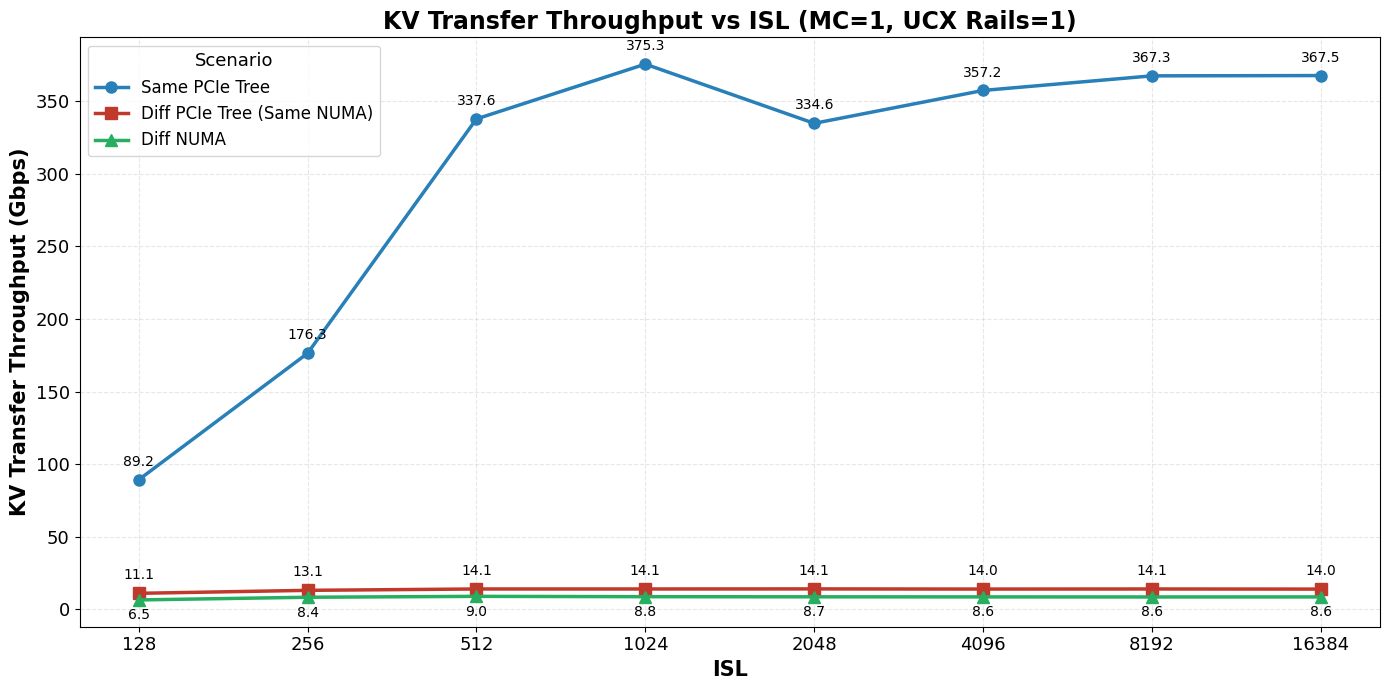

In [22]:
plot_rdma_throughput(
    '../mc1_basic_isl_sweep/mc1_basic_isl_sweep-rdma_throughput.csv',
    title='KV Transfer Throughput vs ISL (MC=1, UCX Rails=1)',
)

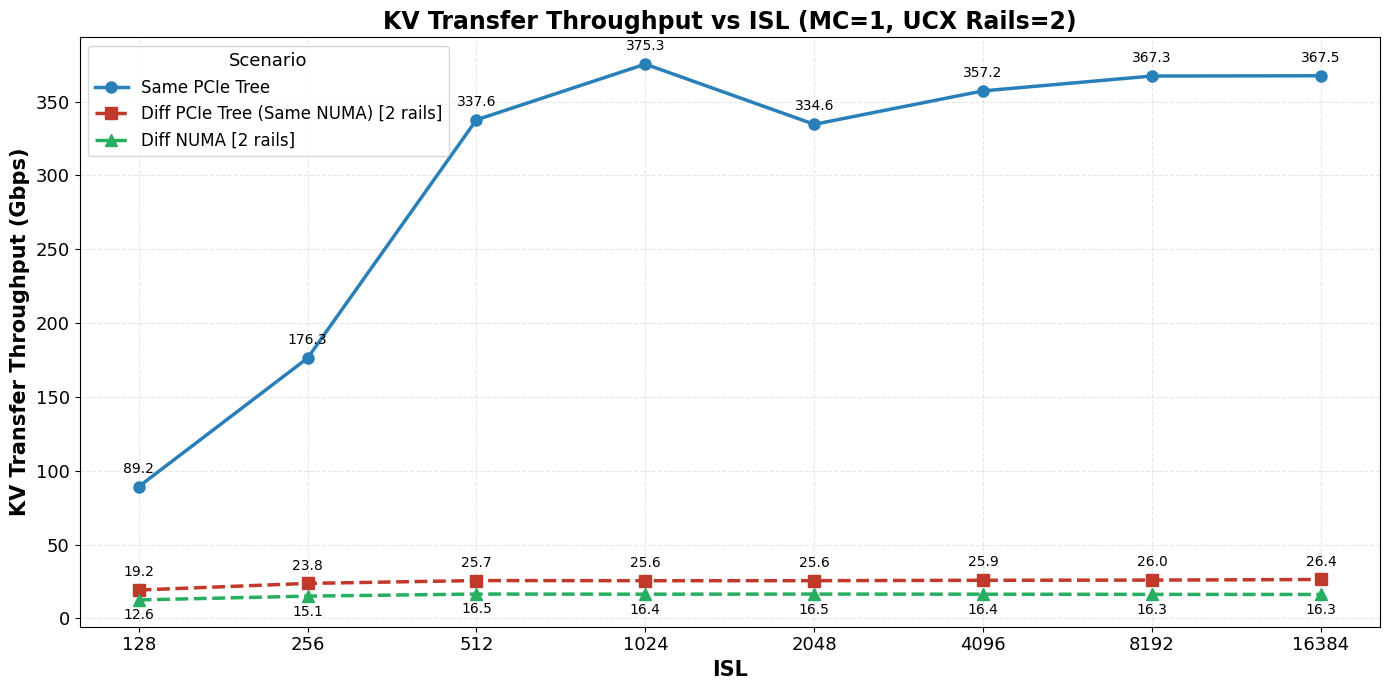

In [23]:
plot_rdma_throughput(
    '../mc1_rails2_isl_sweep/mc1_rails2_isl_sweep-rdma_throughput.csv',
    title='KV Transfer Throughput vs ISL (MC=1, UCX Rails=2)',
)